In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  # Example model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv("../training data/alzheimer_snp_dataset_300.csv")
df

,Patient Name,Age,Gender,Education Level (Years),Genotype,Allele Frequency,SNP_ID,Risk_Allele,Gene,pValue,riskFrequency,beta,Alzheimer
0,Patient_1,66,Male,18,AG,0.314,rs429358,G,ABCA7,0.002711,0.759,1.669,1
1,Patient_2,79,Female,4,AG,0.271,rs744373,C,CLU,0.005928,0.429,1.429,1
2,Patient_3,88,Female,8,AG,0.448,rs17125944,T,SORL1,0.006801,0.457,1.695,1
3,Patient_4,74,Male,11,AG,0.396,rs11767557,T,APOE,0.002308,0.121,1.965,1
4,Patient_5,70,Female,0,AG,0.084,rs3865444,G,CD33,0.004569,0.353,1.281,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Patient_296,82,Female,1,GG,0.269,rs7412,G,TREM2,0.000110,0.034,1.993,1
296,Patient_297,70,Female,10,GG,0.470,rs3865444,T,ABCA7,0.007495,0.870,0.213,0
297,Patient_298,83,Male,18,AG,0.401,rs3865444,T,TREM2,0.007587,0.123,0.106,0
298,Patient_299,86,Male,6,GG,0.499,rs11136000,T,PTK2B,0.006784,0.640,1.316,1


In [3]:
df = pd.get_dummies(df, columns=[
    'Gender',
    'Genotype',
    'SNP_ID',
    'Risk_Allele',
    'Gene'
], drop_first=True)

In [4]:
bool_columns = df.select_dtypes(include=[bool]).columns
df[bool_columns] = df[bool_columns].astype(int)
df.head()

,Patient Name,Age,Education Level (Years),Allele Frequency,pValue,riskFrequency,beta,Alzheimer,Gender_Male,Genotype_AG,...,Gene_BIN1,Gene_CD33,Gene_CLU,Gene_CR1,Gene_EPHA1,Gene_MS4A6A,Gene_PICALM,Gene_PTK2B,Gene_SORL1,Gene_TREM2
0,Patient_1,66,18,0.314,0.002711,0.759,1.669,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,Patient_2,79,4,0.271,0.005928,0.429,1.429,1,0,1,...,0,0,1,0,0,0,0,0,0,0
2,Patient_3,88,8,0.448,0.006801,0.457,1.695,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,Patient_4,74,11,0.396,0.002308,0.121,1.965,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,Patient_5,70,0,0.084,0.004569,0.353,1.281,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [5]:
patient_names = df['Patient Name'].values

In [7]:
# Assuming you're starting with the full DataFrame `df`
X = df.drop(columns=["Alzheimer", 'Patient Name'])
y = df["Alzheimer"]
print(len(X), len(y))

300 300


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [10]:
xgb_model.fit(X_train, y_train)

c:\Users\miche\Documents\Alzheimer test\Alzheimer-s-Disease-Risk-Monitor\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:21:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
y_pred = xgb_model.predict(X_test)

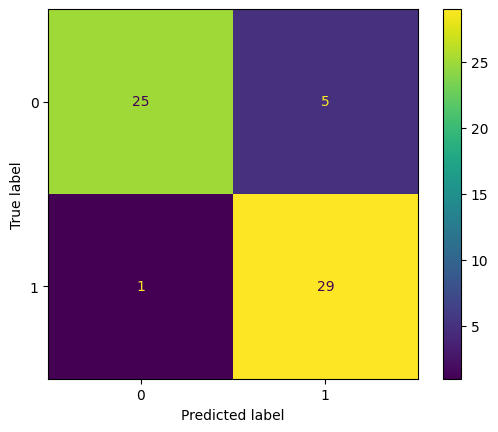

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Precision: 0.8529411764705882
Recall: 0.9666666666666667
F1-score: 0.90625


In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [13]:
import joblib
joblib.dump(xgb_model, 'xgb_trained_model.joblib')

['xgb_trained_model.joblib']